# Data Exploration Notebook
Comprehensive exploration of all asset classes in the Data folder

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 11

## 1. Commodities Data

In [2]:
commodities_path = Path('Data/Commodities')
commodity_tickers = ['BDRY', 'BNO', 'UNG', 'USO']

commodities_data = {}
for ticker in commodity_tickers:
    df = pd.read_parquet(commodities_path / f'{ticker}.parquet')
    commodities_data[ticker] = df

commodities_data['BDRY'].head()

Price,Close
Ticker,BDRY
Date,
2018-12-31,18.17
2019-01-02,18.49
2019-01-03,18.49
2019-01-04,17.92
2019-01-07,17.92


In [3]:
commodities_data['BDRY'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1802 entries, 2018-12-31 to 2026-03-03
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, BDRY)  1802 non-null   float64
dtypes: float64(1)
memory usage: 28.2 KB


In [4]:
commodities_data['BDRY'].describe()

Price,Close
Ticker,BDRY
count,1802.000000
mean,12.497776
std,7.115417
min,3.910000
25%,7.460000
50%,9.950000
75%,16.287499
max,41.509998


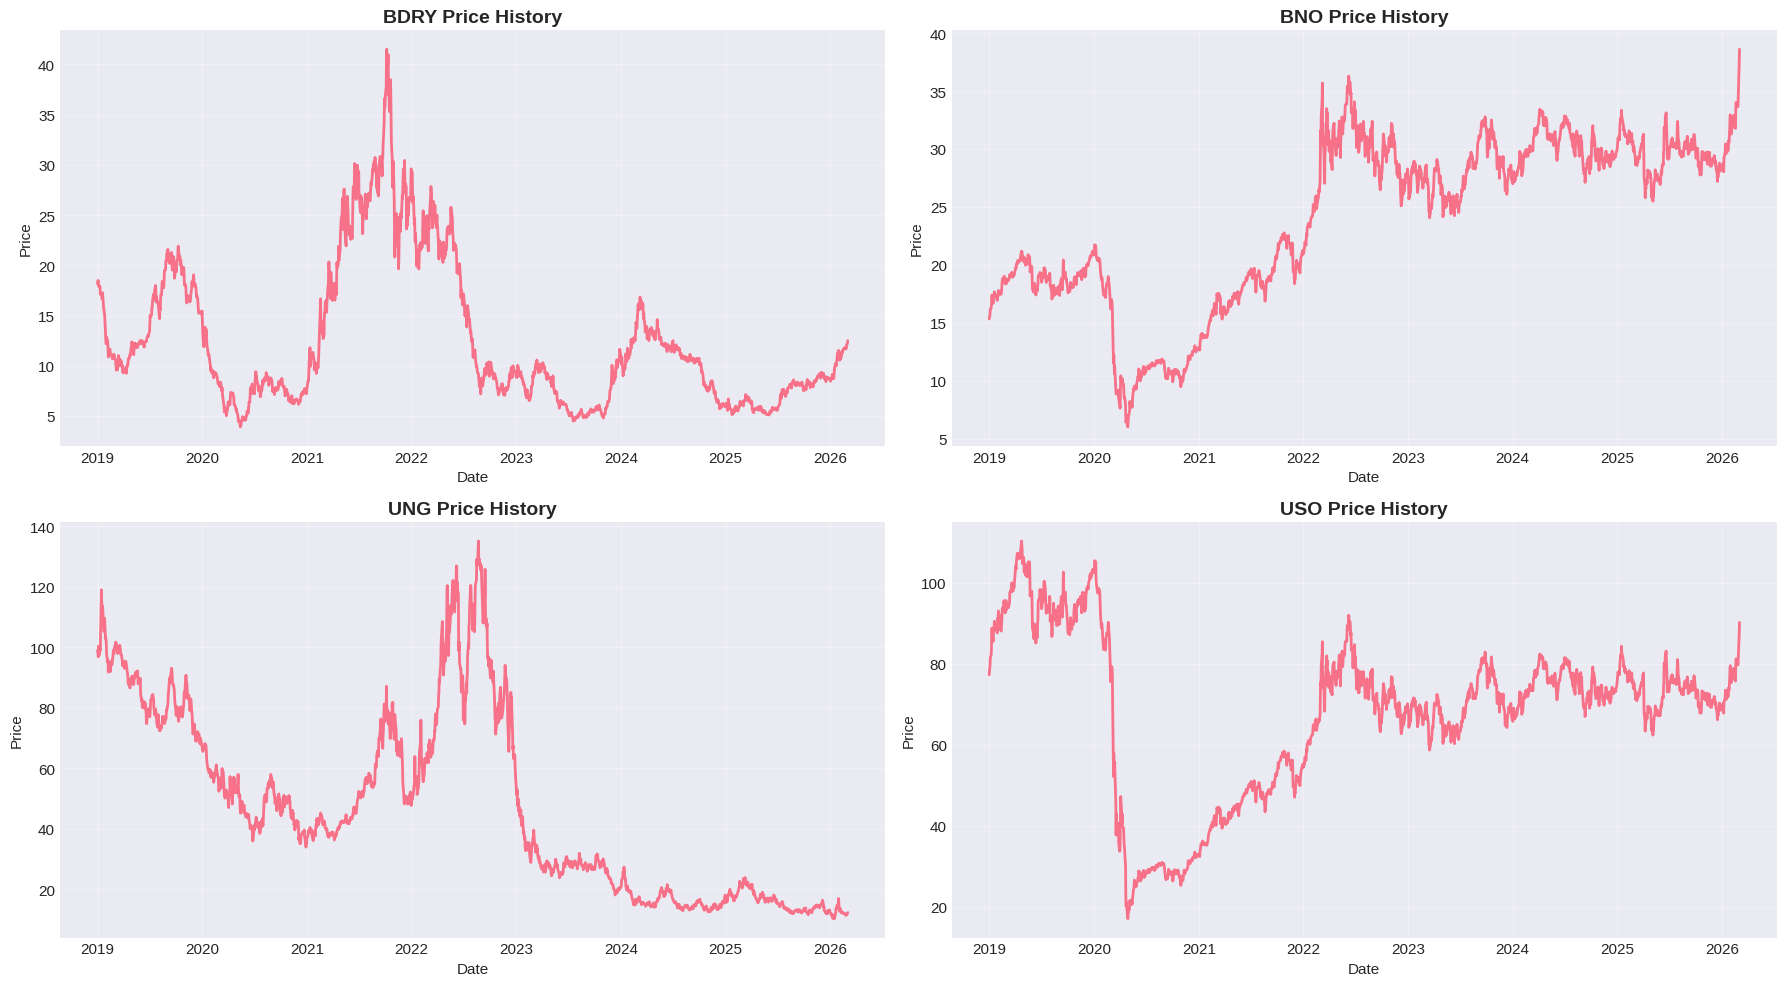

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for idx, ticker in enumerate(commodity_tickers):
    df = commodities_data[ticker]
    axes[idx].plot(df.index, df['Close'], linewidth=2)
    axes[idx].set_title(f'{ticker} Price History', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Price')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Forex Data

In [6]:
forex_path = Path('Data/Forex')
forex_pairs = [
    'AUD_USD_LNG_Exporter',
    'USD_CAD_Oil_Exporter',
    'USD_CNH_Strategic_Importer',
    'USD_INR_Oil_Importer',
    'USD_JPY_Oil_Importer',
    'USD_KRW_Oil_Importer',
    'USD_NOK_Gas_Exporter'
]

forex_data = {}
for pair in forex_pairs:
    df = pd.read_parquet(forex_path / f'{pair}.parquet')
    forex_data[pair] = df

forex_data['USD_JPY_Oil_Importer'].head()

,USD_JPY_Oil_Importer
Date,
2018-12-31,110.330002
2019-01-01,109.629997
2019-01-02,109.667999
2019-01-03,107.441002
2019-01-04,107.807999


In [7]:
forex_data['USD_JPY_Oil_Importer'].describe()

,USD_JPY_Oil_Importer
count,1866.000000
mean,128.961865
std,19.304579
min,102.678001
25%,109.244997
50%,132.053001
75%,147.620502
max,161.621002


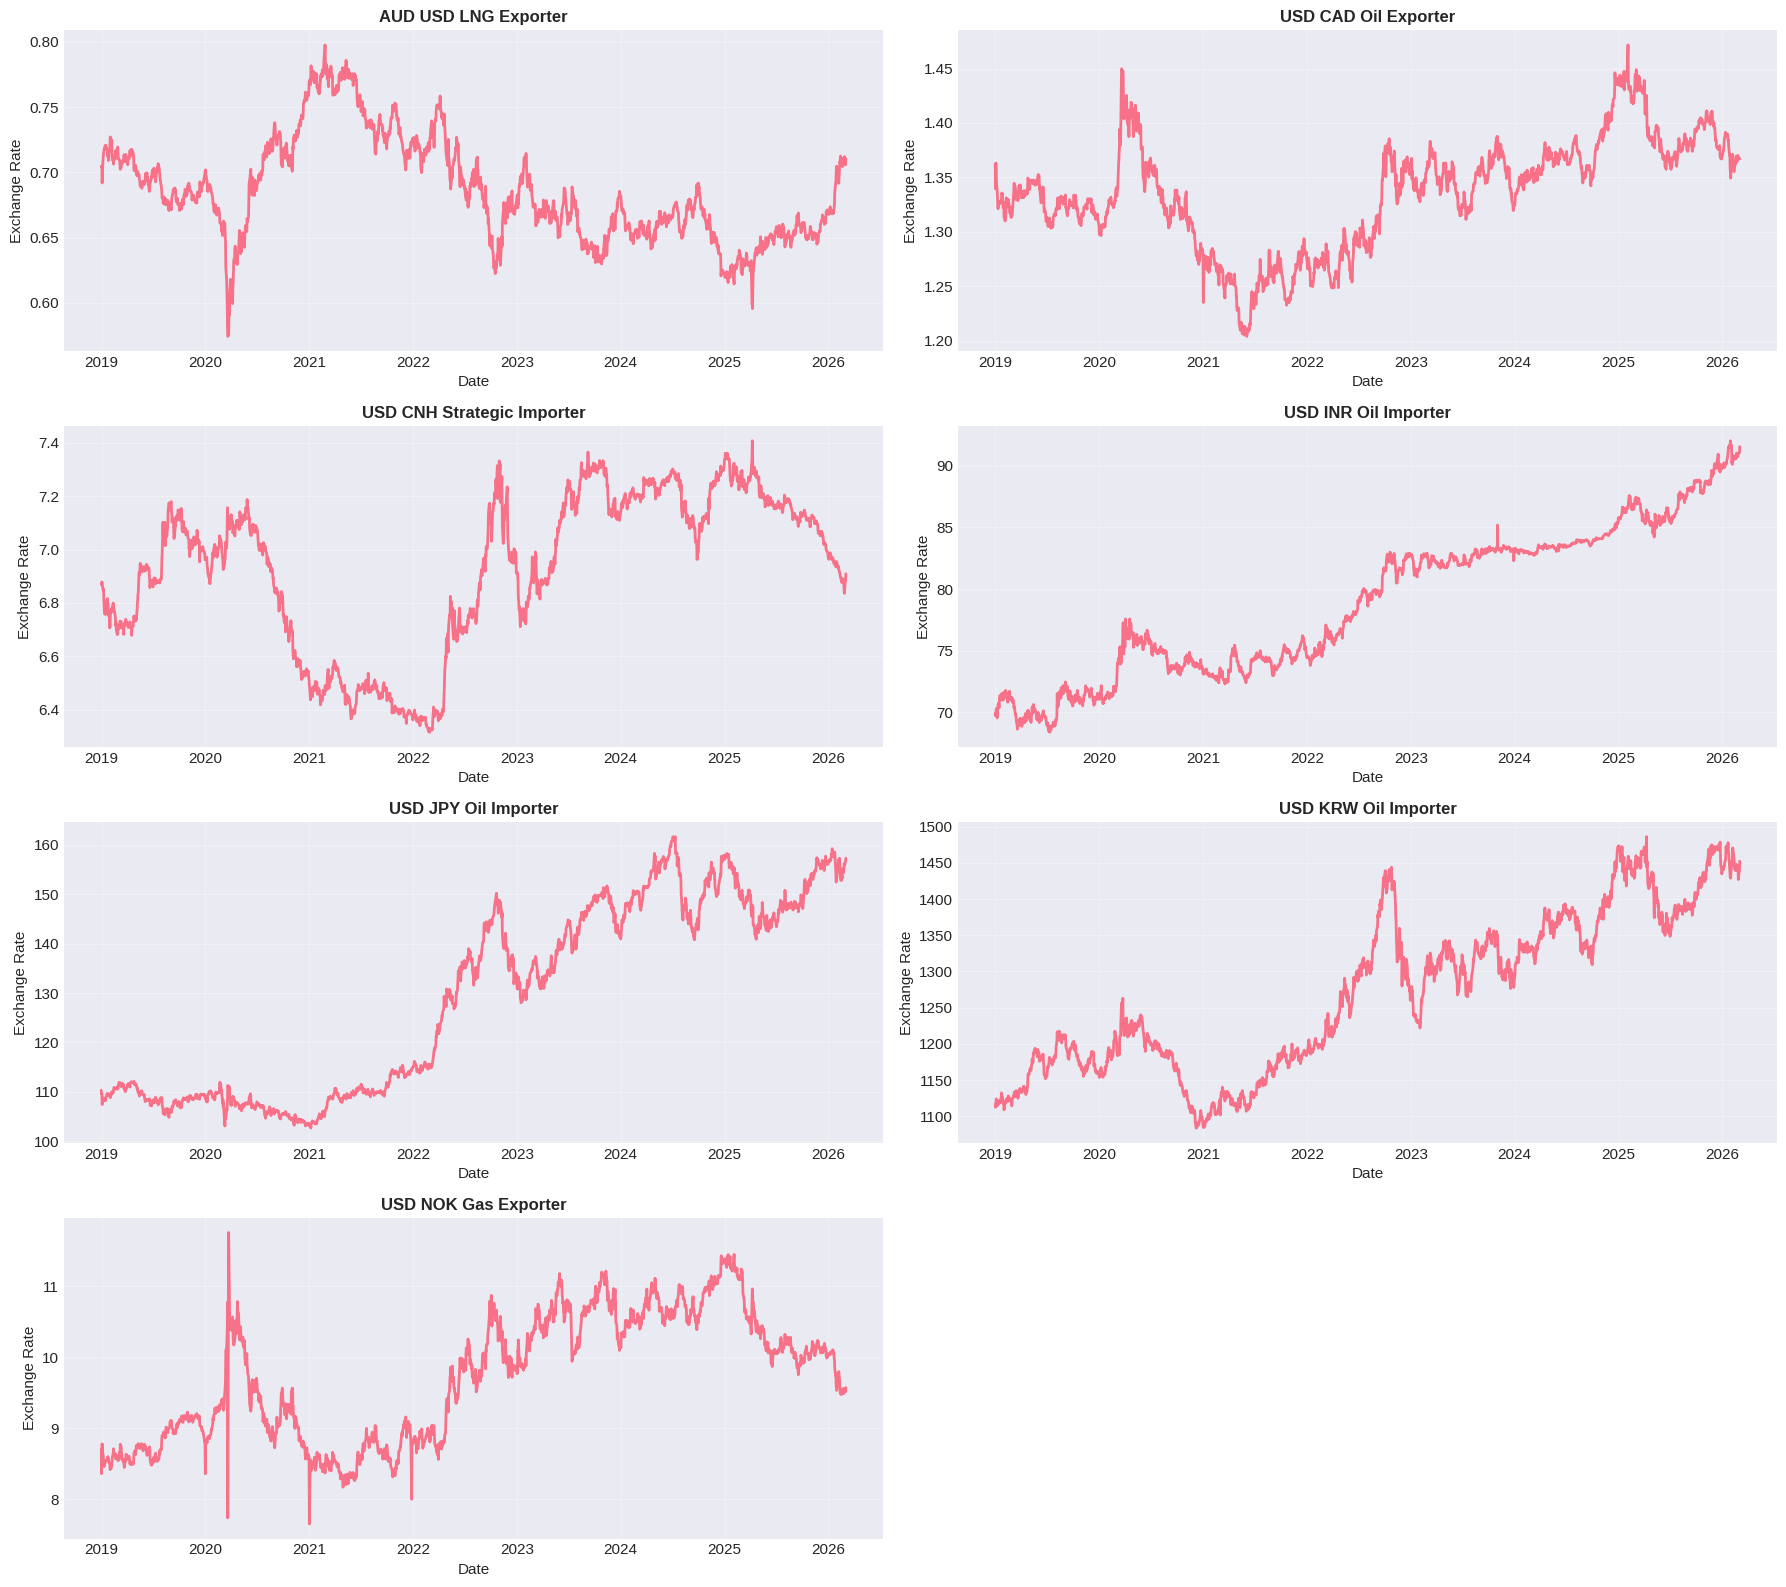

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(18, 16))
axes = axes.flatten()

for idx, pair in enumerate(forex_pairs):
    df = forex_data[pair]
    col_name = df.columns[0]
    axes[idx].plot(df.index, df[col_name], linewidth=2)
    axes[idx].set_title(f'{pair.replace("_", " ")}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Exchange Rate')
    axes[idx].grid(True, alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 3. Fixed Income Data

In [9]:
fixed_income_path = Path('Data/Fixed_Income')
fixed_income_tickers = ['EMB', 'EMLC', 'HYG', 'IEF', 'LQD', 'SHY', 'TLT']

fixed_income_data = {}
for ticker in fixed_income_tickers:
    df = pd.read_parquet(fixed_income_path / f'{ticker}.parquet')
    fixed_income_data[ticker] = df

fixed_income_data['TLT'].head()

Price,Close
Ticker,TLT
Date,
2018-12-31,99.700111
2019-01-02,100.225250
2019-01-03,101.365753
2019-01-04,100.192421
2019-01-07,99.897041


In [10]:
fixed_income_data['TLT'].describe()

Price,Close
Ticker,TLT
count,1802.000000
mean,104.438214
std,19.151469
min,75.124191
25%,87.441576
50%,98.728893
75%,121.032795
max,145.451797


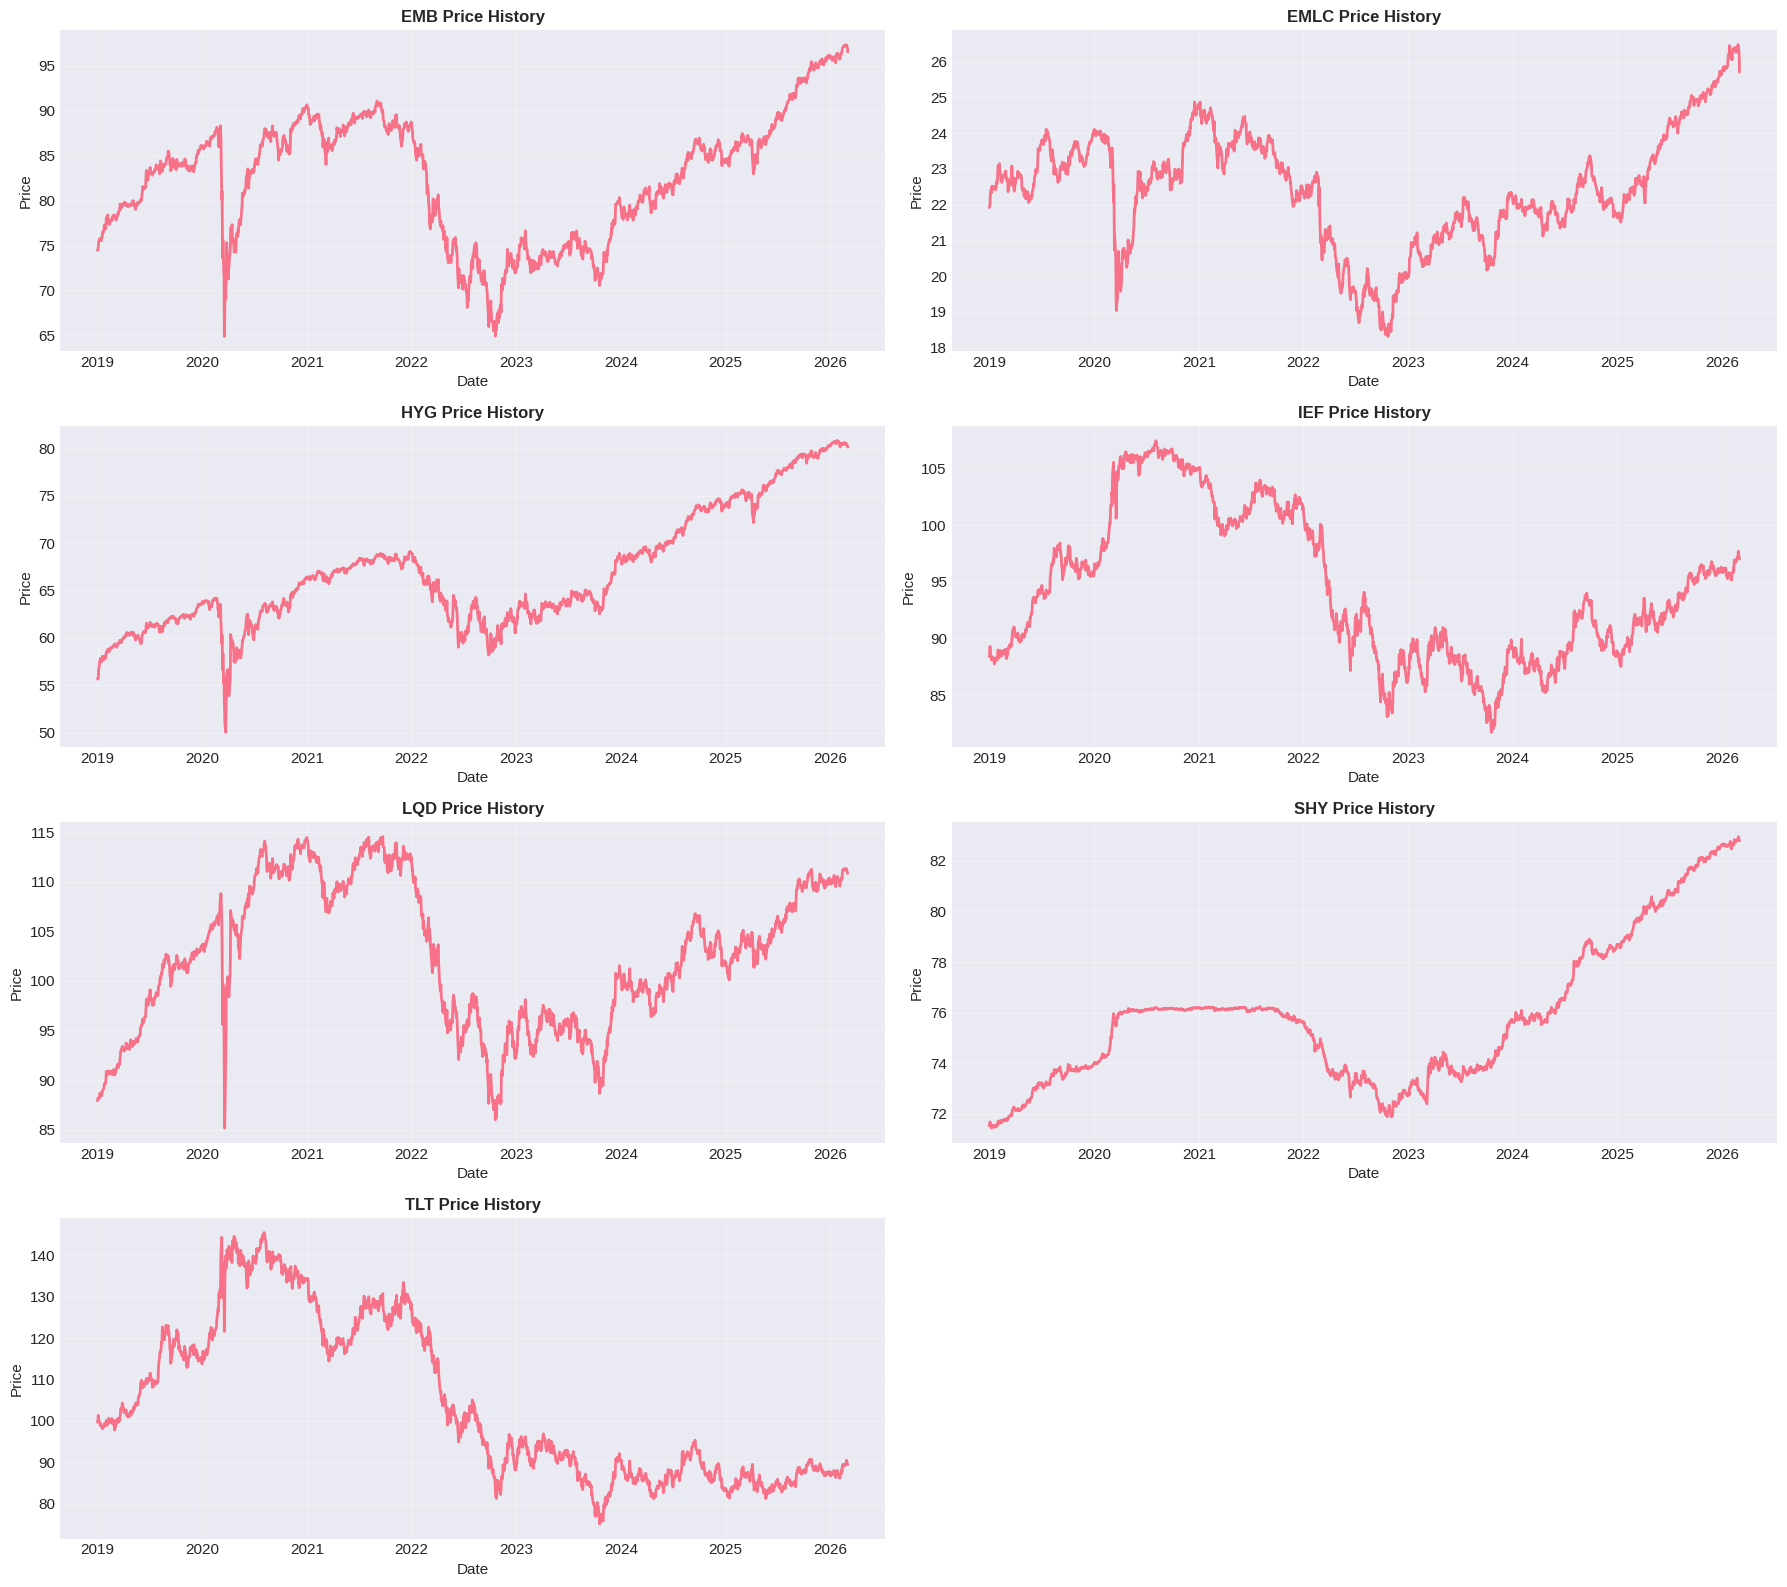

In [11]:
fig, axes = plt.subplots(4, 2, figsize=(18, 16))
axes = axes.flatten()

for idx, ticker in enumerate(fixed_income_tickers):
    df = fixed_income_data[ticker]
    axes[idx].plot(df.index, df['Close'], linewidth=2)
    axes[idx].set_title(f'{ticker} Price History', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Price')
    axes[idx].grid(True, alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 4. Futures Data

In [12]:
futures_path = Path('Data/Futures')
futures_tickers = ['BZ', 'CL', 'ES', 'NG', 'NQ']

futures_data = {}
for ticker in futures_tickers:
    df = pd.read_parquet(futures_path / f'{ticker}.parquet')
    futures_data[ticker] = df

futures_data['CL'].head()

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2019-01-02,46.540001,47.779999,44.349998,45.799999,850480
2019-01-03,47.090000,47.490002,45.349998,46.259998,788718
2019-01-04,47.959999,49.220001,46.650002,46.900002,817277
2019-01-07,48.520000,49.790001,48.110001,48.299999,819939
2019-01-08,49.779999,49.950001,48.310001,48.730000,765981


In [13]:
futures_data['CL'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1552 entries, 2019-01-02 to 2025-03-04
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, CL=F)   1552 non-null   float64
 1   (High, CL=F)    1552 non-null   float64
 2   (Low, CL=F)     1552 non-null   float64
 3   (Open, CL=F)    1552 non-null   float64
 4   (Volume, CL=F)  1552 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 72.8 KB


In [14]:
futures_data['CL'].describe()

Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
count,1552.000000,1552.000000,1552.000000,1552.000000,1.552000e+03
mean,68.766443,70.033982,67.483415,68.809259,4.037025e+05
std,18.962290,19.167622,18.701845,18.915509,2.024125e+05
min,-37.630001,13.690000,-40.320000,-14.000000,0.000000e+00
25%,56.732501,57.480000,55.810001,56.697500,2.913345e+05
50%,71.035000,72.189999,69.989998,71.150002,3.595720e+05
75%,79.995003,81.180000,78.725002,80.055000,4.869598e+05
max,123.699997,130.500000,120.790001,124.660004,2.288230e+06


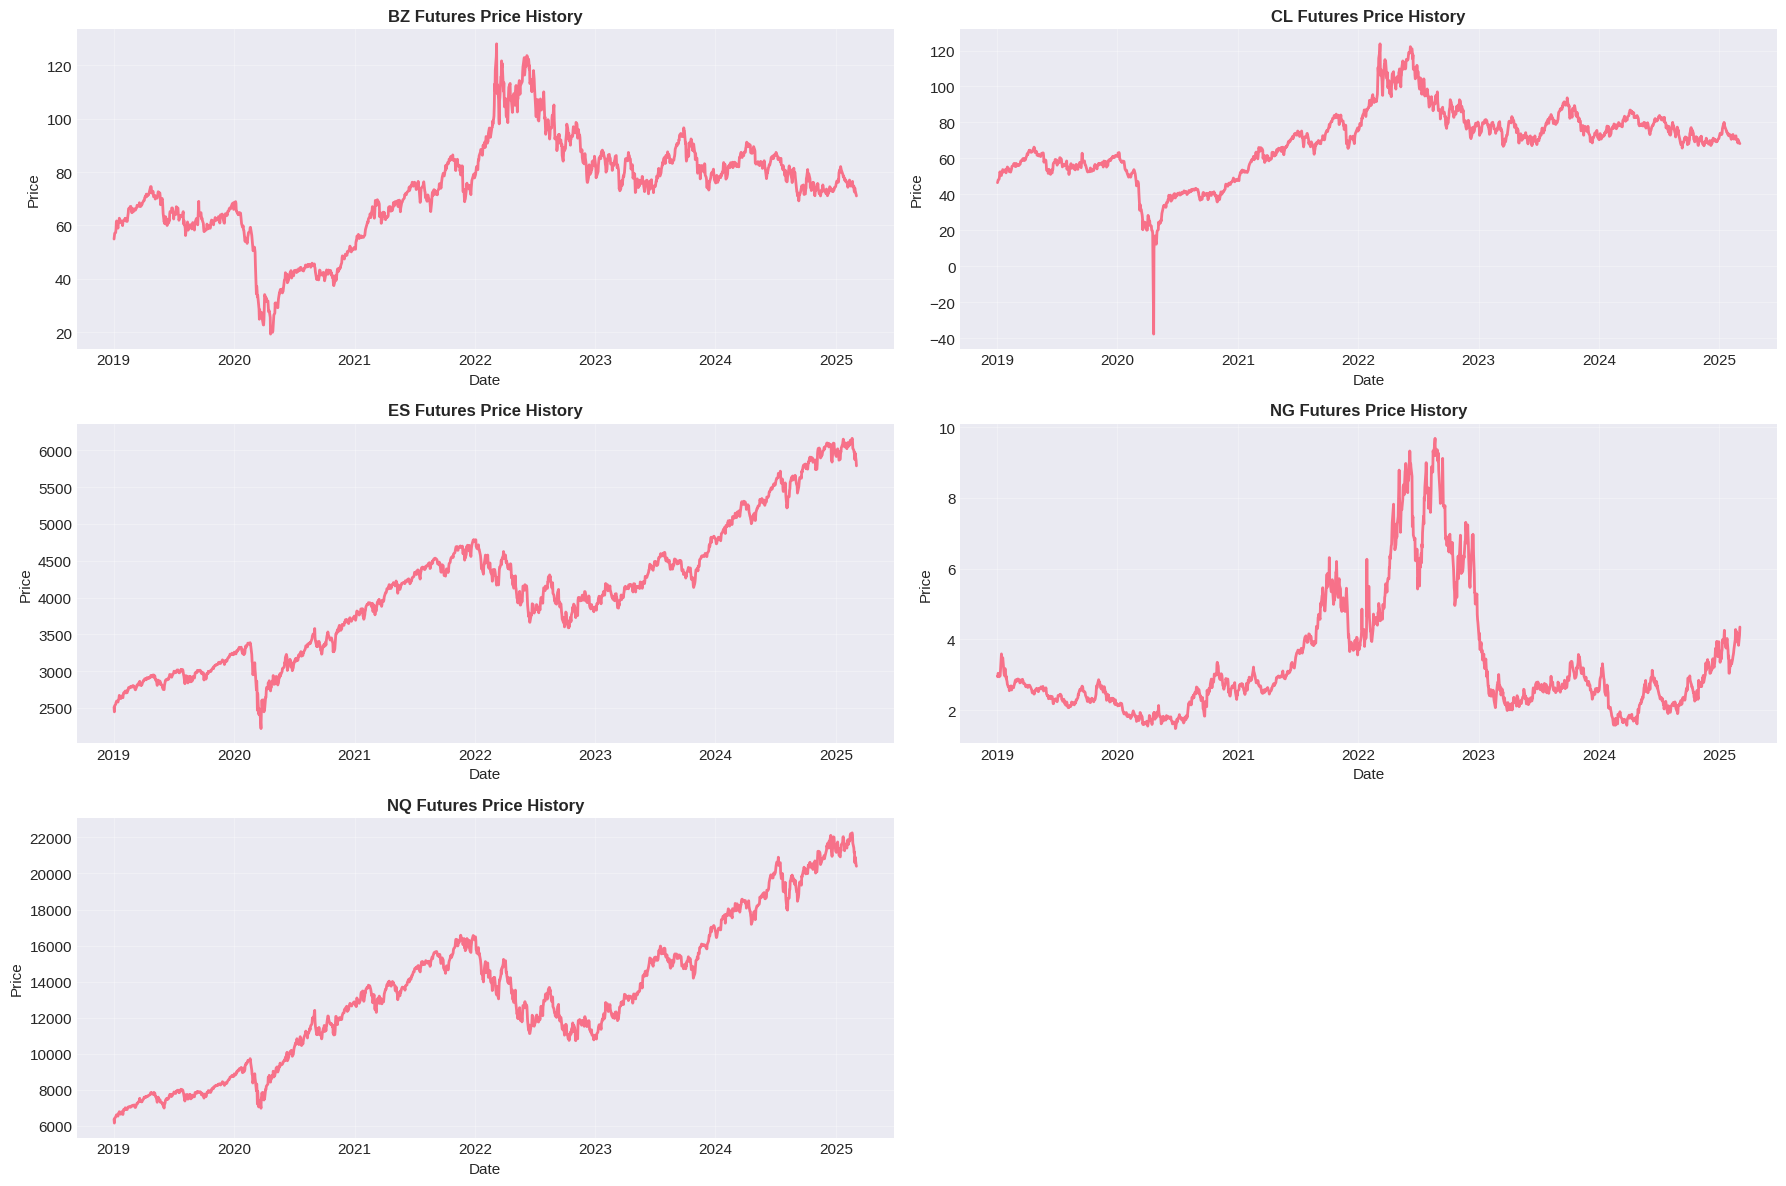

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, ticker in enumerate(futures_tickers):
    df = futures_data[ticker]
    axes[idx].plot(df.index, df['Close'], linewidth=2)
    axes[idx].set_title(f'{ticker} Futures Price History', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Price')
    axes[idx].grid(True, alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 5. Equities Data - US

In [17]:
equities_us_path = Path('Data/Equities/US')
us_tickers = ['BA', 'COP', 'CVX', 'DHT', 'EOG', 'FRO', 'HAL', 'ITA', 'JETS', 
              'LMT', 'LNG', 'SLB', 'SPY', 'STNG', 'TNK', 'WDS', 'XLE', 'XLI', 'XOM']

equities_us_data = {}
for ticker in us_tickers:
    df = pd.read_parquet(equities_us_path / f'{ticker}.parquet')
    equities_us_data[ticker] = df

equities_us_data['SPY'].head()

Price,Close
Ticker,SPY
Date,
2018-12-31,224.761505
2019-01-02,224.995346
2019-01-03,219.626282
2019-01-04,226.982895
2019-01-07,228.772476


In [18]:
equities_us_data['SPY'].describe()

Price,Close
Ticker,SPY
count,1802.000000
mean,421.620643
std,124.167828
min,205.504608
25%,319.381058
50%,402.375504
75%,509.905510
max,695.489990


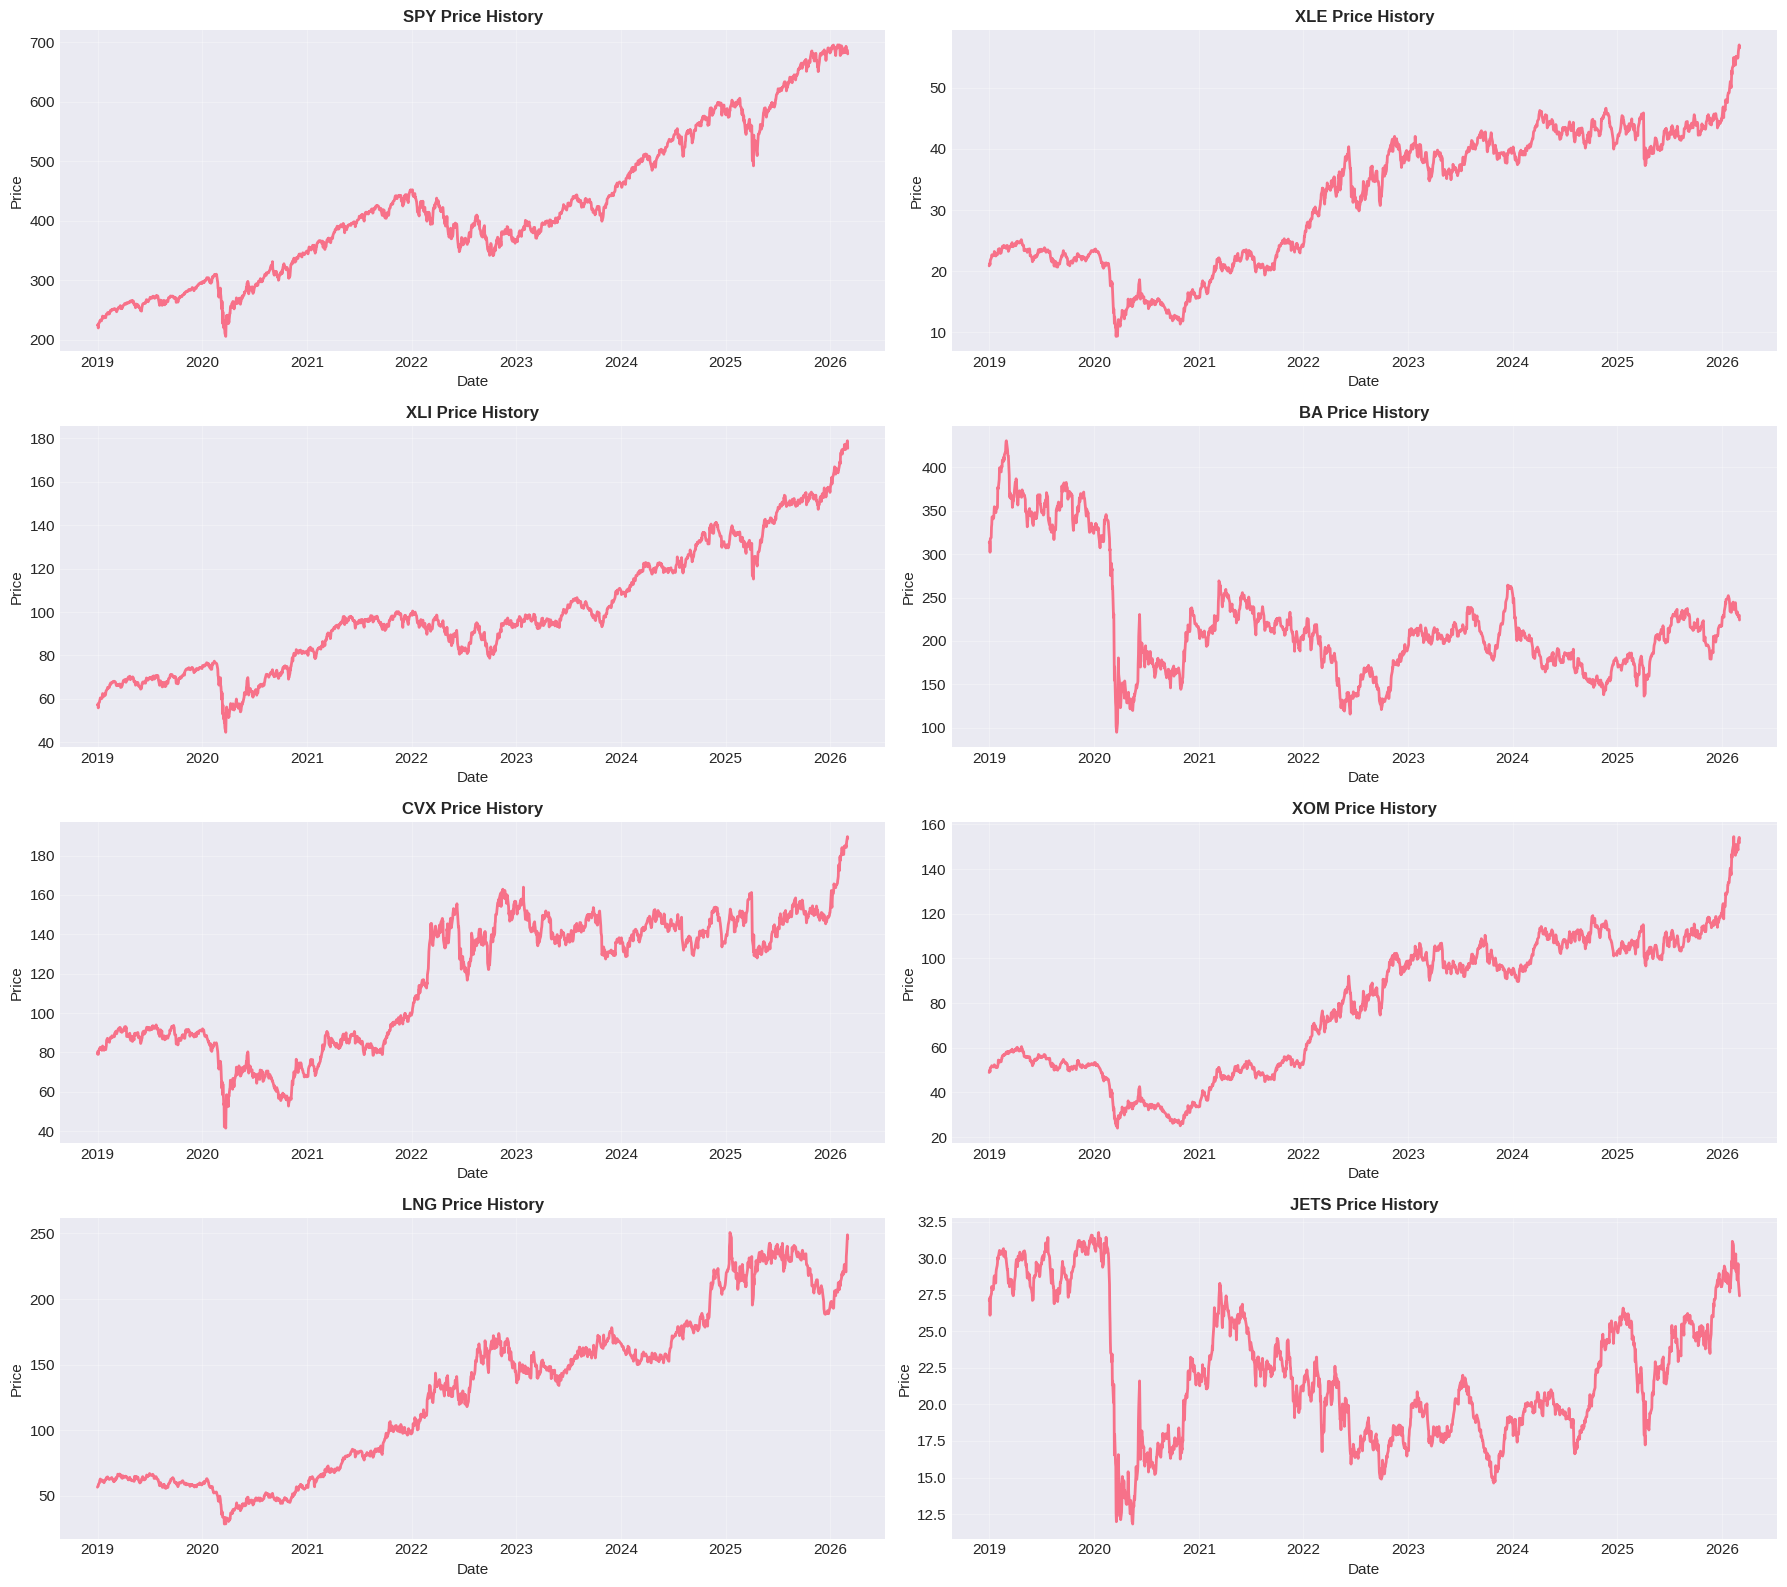

In [19]:
key_us_tickers = ['SPY', 'XLE', 'XLI', 'BA', 'CVX', 'XOM', 'LNG', 'JETS']

fig, axes = plt.subplots(4, 2, figsize=(18, 16))
axes = axes.flatten()

for idx, ticker in enumerate(key_us_tickers):
    df = equities_us_data[ticker]
    axes[idx].plot(df.index, df['Close'], linewidth=2)
    axes[idx].set_title(f'{ticker} Price History', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Price')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Equities Data - Asia

In [20]:
equities_asia_path = Path('Data/Equities/Asia')
asia_tickers = ['ASHR', 'DXJ', 'EWA', 'EWJ', 'EWT', 'EWY', 'FXI', 'INDA', 'INDY', 'MCHI']

equities_asia_data = {}
for ticker in asia_tickers:
    df = pd.read_parquet(equities_asia_path / f'{ticker}.parquet')
    equities_asia_data[ticker] = df

equities_asia_data['EWJ'].head()

Price,Close
Ticker,EWJ
Date,
2018-12-31,43.475853
2019-01-02,43.776043
2019-01-03,43.527321
2019-01-04,45.002529
2019-01-07,45.114017


In [21]:
equities_asia_data['EWJ'].describe()

Price,Close
Ticker,EWJ
count,1802.000000
mean,58.179202
std,9.911585
min,37.852612
25%,50.404408
50%,57.500458
75%,63.898287
max,93.970001


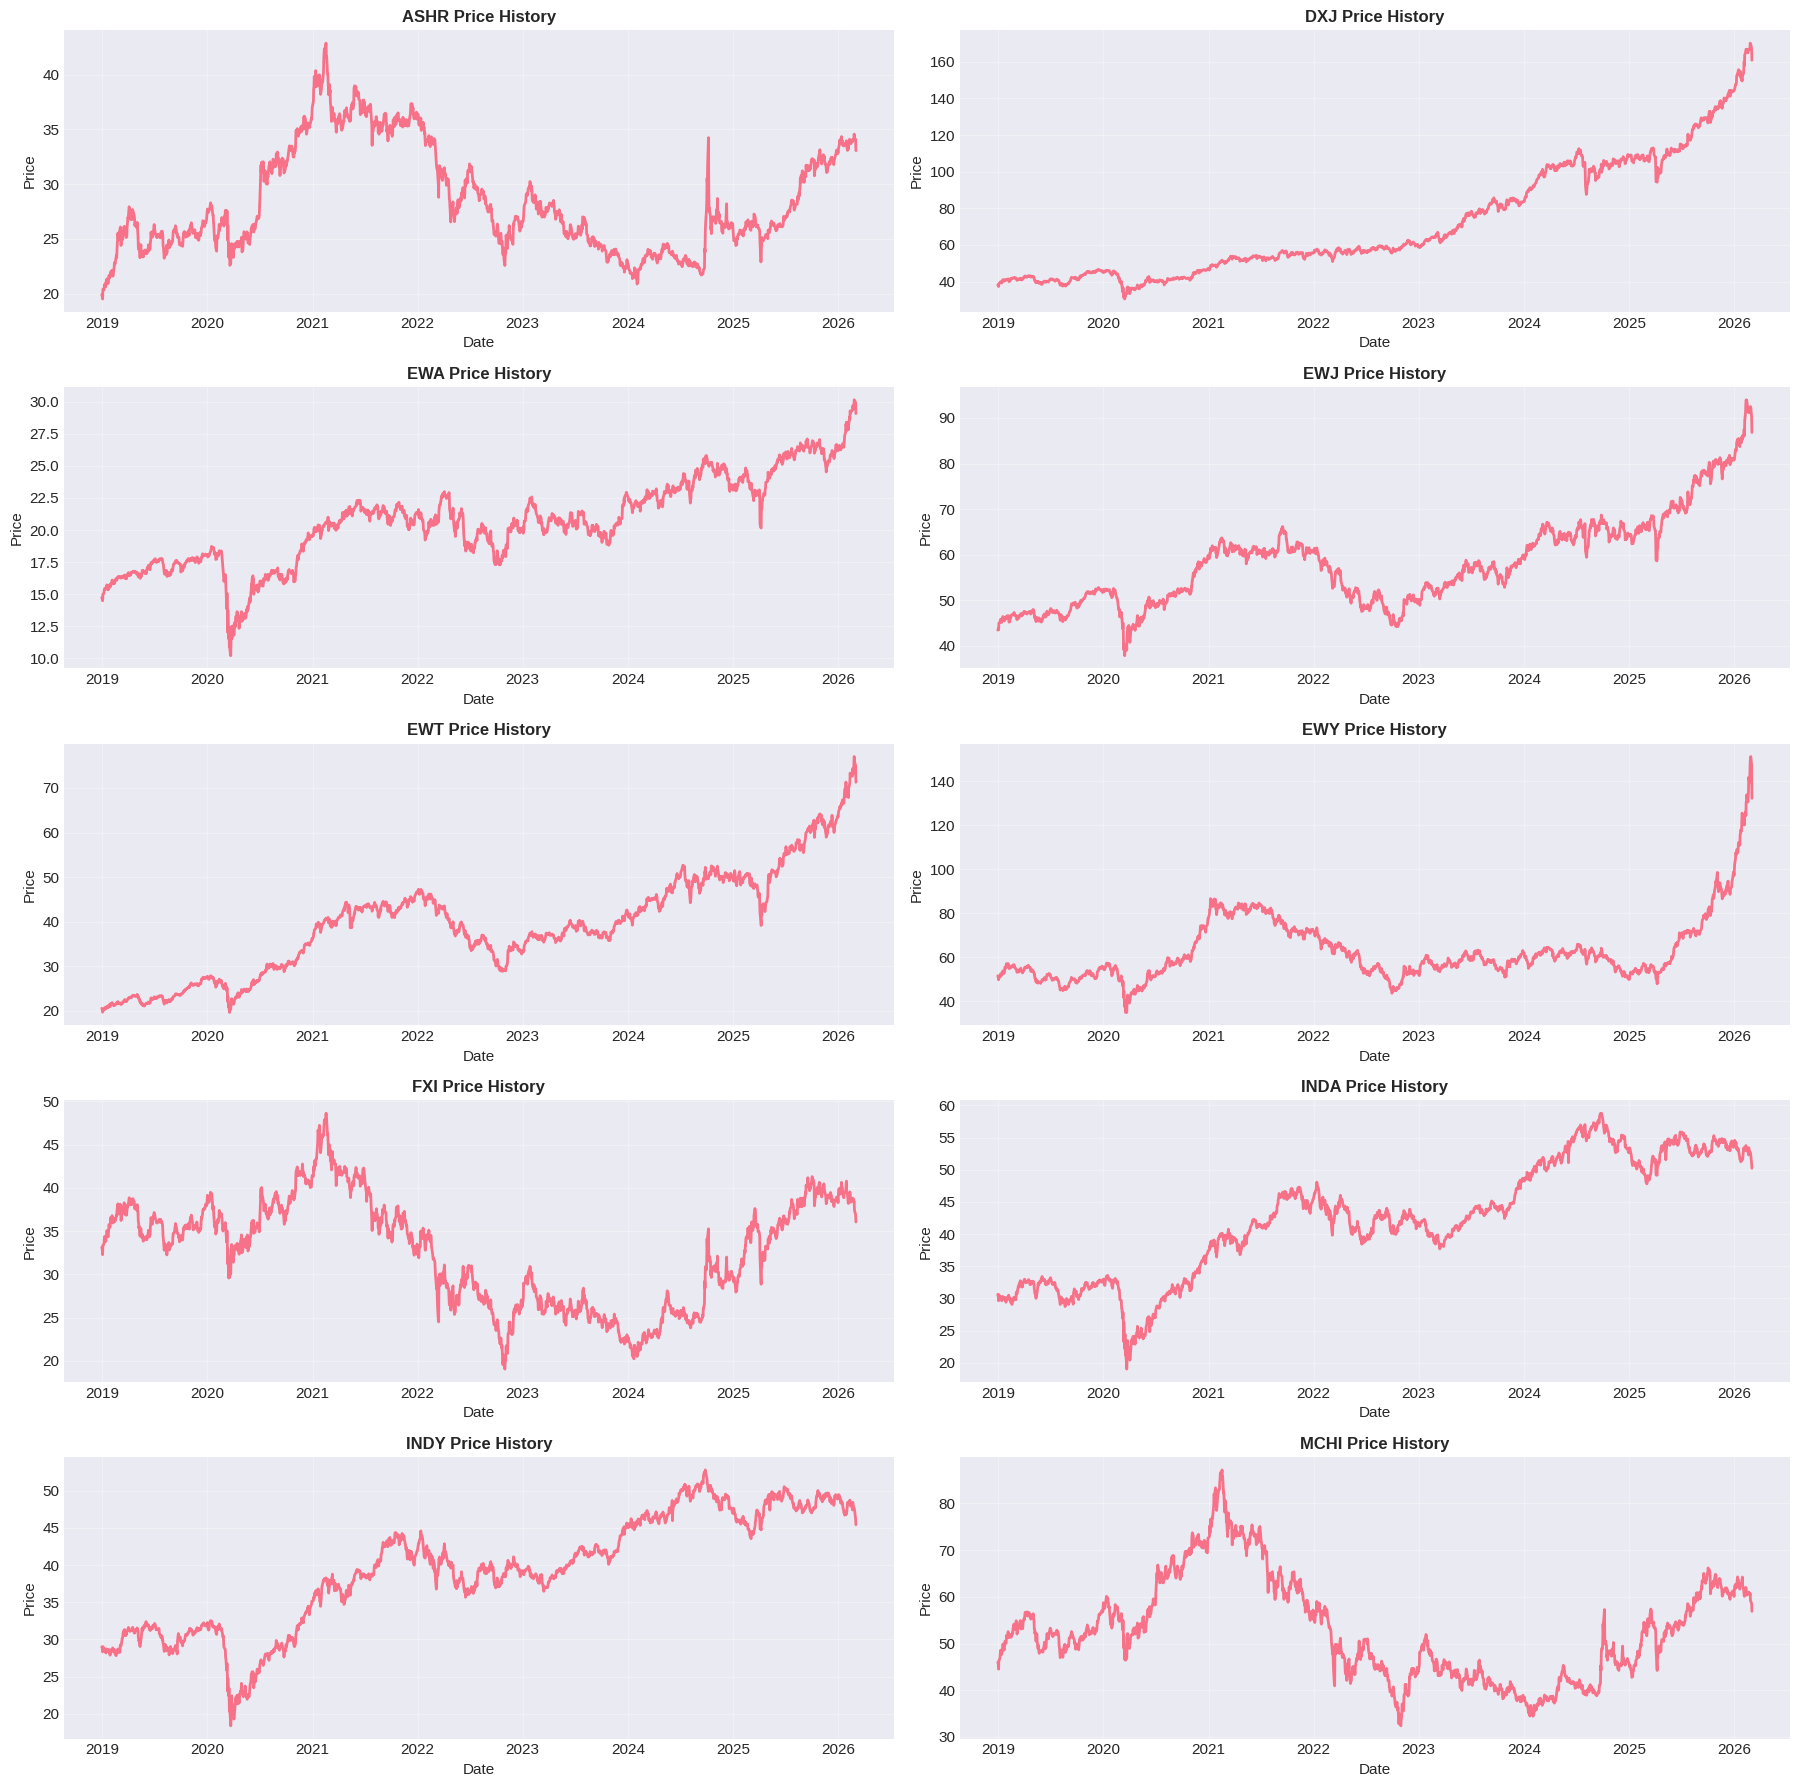

In [22]:
fig, axes = plt.subplots(5, 2, figsize=(18, 18))
axes = axes.flatten()

for idx, ticker in enumerate(asia_tickers):
    df = equities_asia_data[ticker]
    axes[idx].plot(df.index, df['Close'], linewidth=2)
    axes[idx].set_title(f'{ticker} Price History', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Price')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Equities Data - Europe

In [23]:
equities_europe_path = Path('Data/Equities/Europe')
europe_tickers = ['DXGE', 'EPOL', 'EQNR', 'EWG', 'EWI', 'EZU', 'IEO', 'NORW']

equities_europe_data = {}
for ticker in europe_tickers:
    df = pd.read_parquet(equities_europe_path / f'{ticker}.parquet')
    equities_europe_data[ticker] = df

equities_europe_data['EWG'].head()

Price,Close
Ticker,EWG
Date,
2018-12-31,21.319593
2019-01-02,21.159803
2019-01-03,20.882267
2019-01-04,21.664406
2019-01-07,21.698048


In [24]:
equities_europe_data['EWG'].describe()

Price,Close
Ticker,EWG
count,1802.000000
mean,28.586618
std,6.168647
min,15.578609
25%,24.095703
50%,27.272959
75%,31.105017
max,44.560001


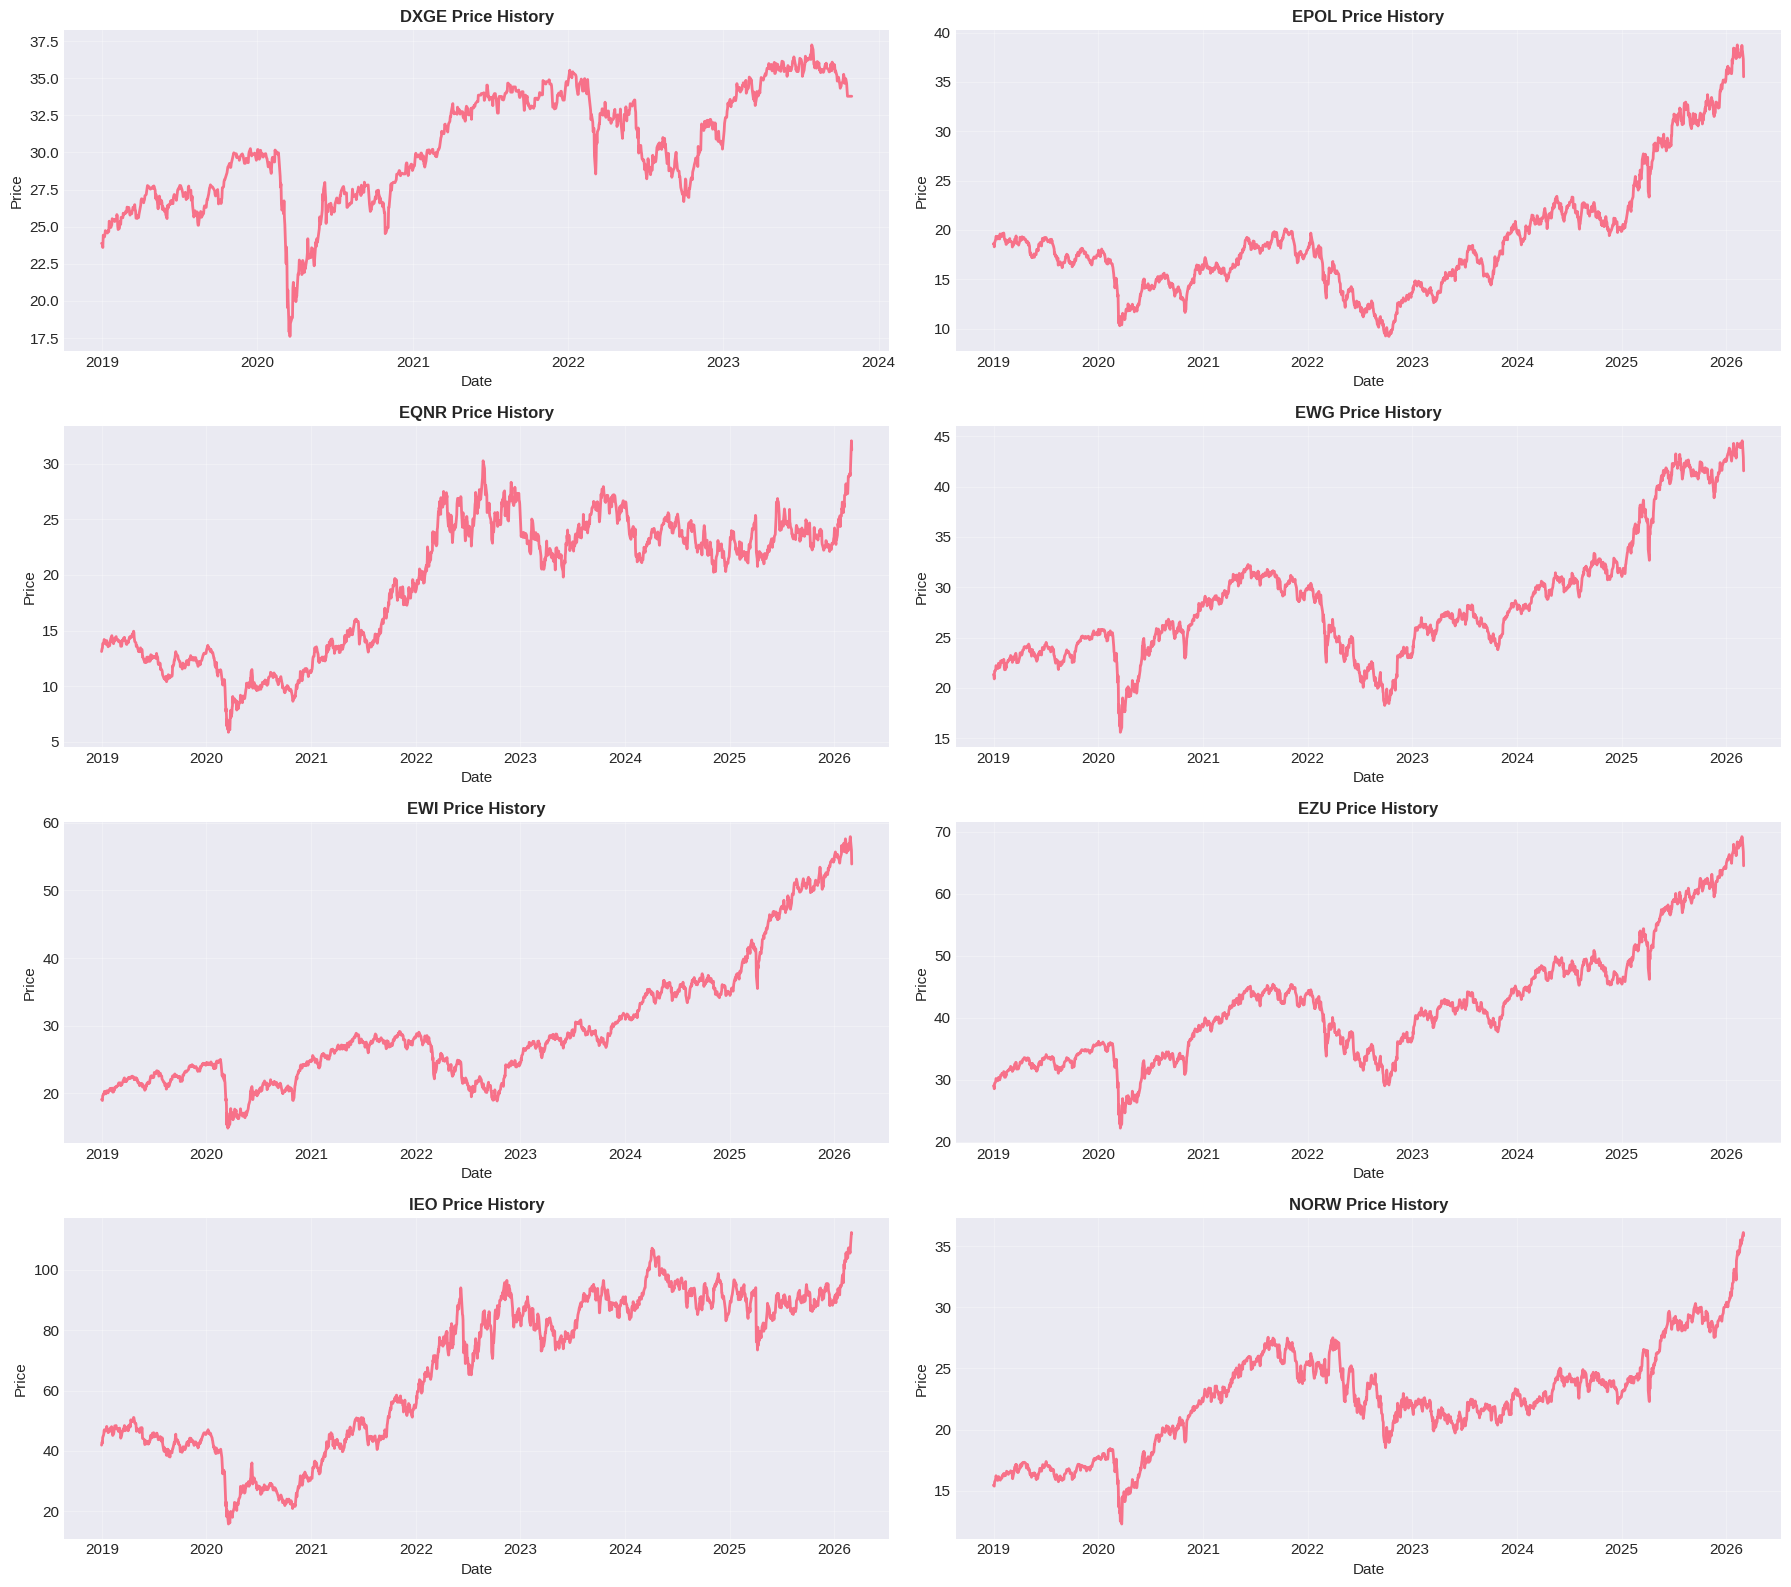

In [25]:
fig, axes = plt.subplots(4, 2, figsize=(18, 16))
axes = axes.flatten()

for idx, ticker in enumerate(europe_tickers):
    df = equities_europe_data[ticker]
    axes[idx].plot(df.index, df['Close'], linewidth=2)
    axes[idx].set_title(f'{ticker} Price History', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Price')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Portwatch Shipment Data

In [26]:
arrivals_df = pd.read_csv('Data/Portwatch_Shipment_Data/arrivals-of-ships.csv')
arrivals_df.head()

,DateTime,Container,Dry Bulk,General Cargo,Roll-on/roll-off,Tanker,7-day Moving Average,Prior Year: 7-day Moving Average
0,2019-01-01 00:00:00,11,11,3,3,51,NaN,NaN
1,2019-01-02 00:00:00,13,11,0,4,55,NaN,NaN
2,2019-01-03 00:00:00,15,15,5,1,58,NaN,NaN
3,2019-01-04 00:00:00,10,14,2,2,41,NaN,NaN
4,2019-01-05 00:00:00,12,14,3,1,51,NaN,NaN


In [27]:
arrivals_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2617 entries, 0 to 2616
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   DateTime                          2617 non-null   object 
 1   Container                         2617 non-null   int64  
 2   Dry Bulk                          2617 non-null   int64  
 3   General Cargo                     2617 non-null   int64  
 4   Roll-on/roll-off                  2617 non-null   int64  
 5   Tanker                            2617 non-null   int64  
 6   7-day Moving Average              2611 non-null   float64
 7   Prior Year: 7-day Moving Average  2246 non-null   float64
dtypes: float64(2), int64(5), object(1)
memory usage: 163.7+ KB


In [28]:
arrivals_df.describe()

,Container,Dry Bulk,General Cargo,Roll-on/roll-off,Tanker,7-day Moving Average,Prior Year: 7-day Moving Average
count,2617.000000,2617.000000,2617.000000,2617.000000,2617.000000,2611.000000,2246.000000
mean,14.694689,15.470386,4.155904,2.353076,55.927780,92.638234,92.553746
std,4.641138,4.220325,2.197127,1.634603,10.686371,11.873909,9.902294
min,2.000000,4.000000,0.000000,0.000000,11.000000,51.285714,68.000000
25%,11.000000,13.000000,3.000000,1.000000,49.000000,84.857143,85.000000
50%,14.000000,15.000000,4.000000,2.000000,56.000000,91.571429,91.142857
75%,18.000000,18.000000,6.000000,3.000000,63.000000,102.000000,100.571429
max,32.000000,30.000000,17.000000,11.000000,90.000000,120.571429,116.714286


In [29]:
chart_df = pd.read_csv('Data/Portwatch_Shipment_Data/chart.csv')
chart_df.head()

,DateTime,Container,Dry Bulk,General Cargo,Roll-on/roll-off,Tanker,7-day Moving Average,Prior Year: 7-day Moving Average
0,2019-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-04 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
chart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2617 entries, 0 to 2616
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   DateTime                          2617 non-null   object 
 1   Container                         0 non-null      float64
 2   Dry Bulk                          0 non-null      float64
 3   General Cargo                     0 non-null      float64
 4   Roll-on/roll-off                  0 non-null      float64
 5   Tanker                            0 non-null      float64
 6   7-day Moving Average              2611 non-null   float64
 7   Prior Year: 7-day Moving Average  2246 non-null   float64
dtypes: float64(7), object(1)
memory usage: 163.7+ KB


In [31]:
chart_df.describe()

,Container,Dry Bulk,General Cargo,Roll-on/roll-off,Tanker,7-day Moving Average,Prior Year: 7-day Moving Average
count,0.0,0.0,0.0,0.0,0.0,2.611000e+03,2.246000e+03
mean,NaN,NaN,NaN,NaN,NaN,3.609693e+06,3.627020e+06
std,NaN,NaN,NaN,NaN,NaN,5.649099e+05,5.346782e+05
min,NaN,NaN,NaN,NaN,NaN,1.698014e+06,1.698014e+06
25%,NaN,NaN,NaN,NaN,NaN,3.307550e+06,3.336765e+06
50%,NaN,NaN,NaN,NaN,NaN,3.701909e+06,3.696300e+06
75%,NaN,NaN,NaN,NaN,NaN,4.016428e+06,4.009107e+06
max,NaN,NaN,NaN,NaN,NaN,4.923856e+06,4.923856e+06


## 9. Cross-Asset Correlation Analysis

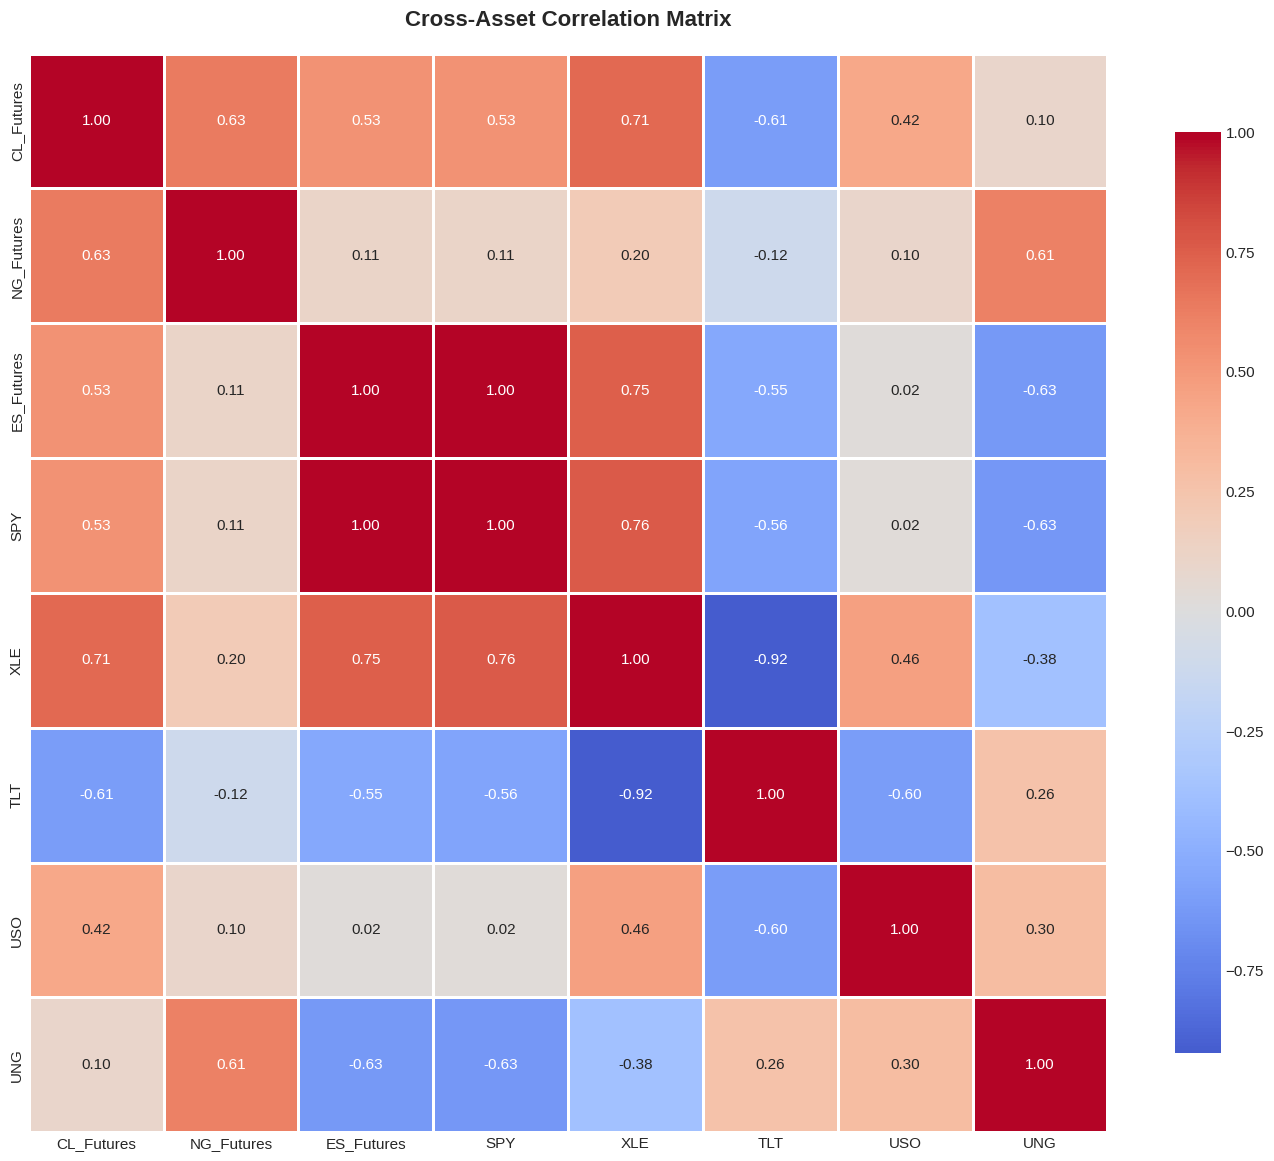

In [34]:
combined_df = pd.DataFrame()

combined_df['CL_Futures'] = futures_data['CL']['Close']
combined_df['NG_Futures'] = futures_data['NG']['Close']
combined_df['ES_Futures'] = futures_data['ES']['Close']
combined_df['SPY'] = equities_us_data['SPY']['Close']
combined_df['XLE'] = equities_us_data['XLE']['Close']
combined_df['TLT'] = fixed_income_data['TLT']['Close']
combined_df['USO'] = commodities_data['USO']['Close']
combined_df['UNG'] = commodities_data['UNG']['Close']

combined_df = combined_df.dropna()

correlation_matrix = combined_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Cross-Asset Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

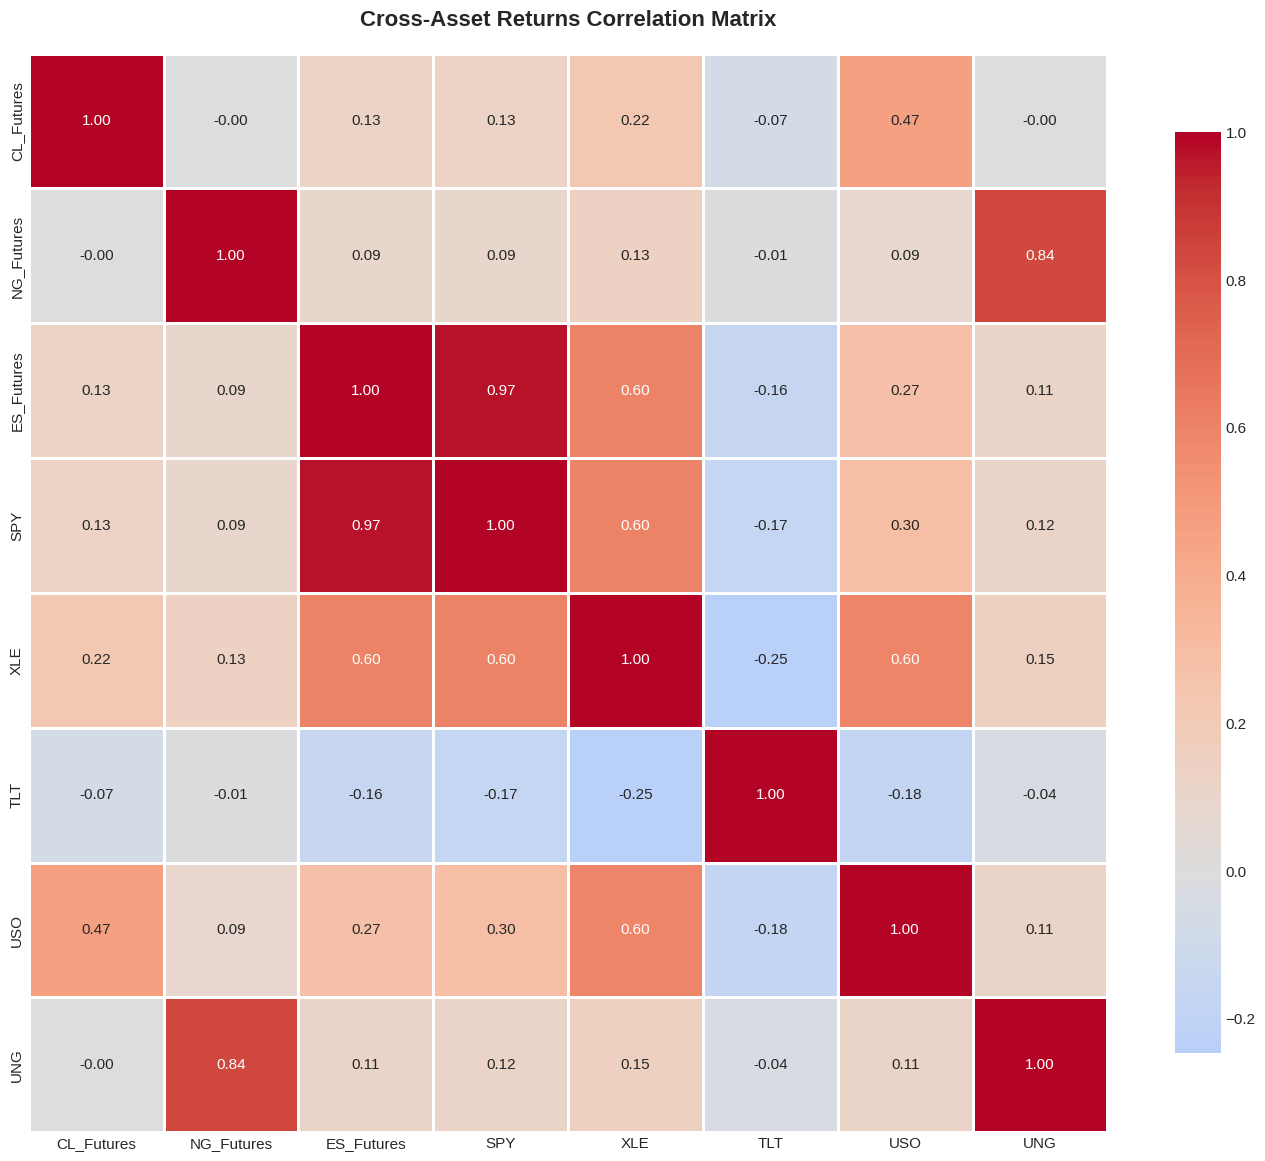

In [35]:
returns_df = combined_df.pct_change().dropna()

returns_correlation = returns_df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(returns_correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Cross-Asset Returns Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 10. Data Summary Statistics

In [36]:
summary_stats = pd.DataFrame({
    'Asset Class': ['Commodities', 'Forex', 'Fixed Income', 'Futures', 'Equities US', 'Equities Asia', 'Equities Europe'],
    'Number of Assets': [len(commodity_tickers), len(forex_pairs), len(fixed_income_tickers), 
                         len(futures_tickers), len(us_tickers), len(asia_tickers), len(europe_tickers)]
})

summary_stats

,Asset Class,Number of Assets
0,Commodities,4
1,Forex,7
2,Fixed Income,7
3,Futures,5
4,Equities US,19
5,Equities Asia,10
6,Equities Europe,8


In [37]:
date_ranges = {}

date_ranges['CL_Futures'] = (futures_data['CL'].index.min(), futures_data['CL'].index.max())
date_ranges['SPY'] = (equities_us_data['SPY'].index.min(), equities_us_data['SPY'].index.max())
date_ranges['TLT'] = (fixed_income_data['TLT'].index.min(), fixed_income_data['TLT'].index.max())
date_ranges['USD_JPY'] = (forex_data['USD_JPY_Oil_Importer'].index.min(), forex_data['USD_JPY_Oil_Importer'].index.max())
date_ranges['USO'] = (commodities_data['USO'].index.min(), commodities_data['USO'].index.max())

date_ranges_df = pd.DataFrame(date_ranges, index=['Start Date', 'End Date']).T
date_ranges_df

,Start Date,End Date
CL_Futures,2019-01-02,2025-03-04
SPY,2018-12-31,2026-03-03
TLT,2018-12-31,2026-03-03
USD_JPY,2018-12-31,2026-03-03
USO,2018-12-31,2026-03-03
